# HW2

## lecture 2 : digital image processing

20230708041 송동선

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

### HW2-1

Fig3.9(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고, 결과를 분석하시오

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"
resp = requests.get(url)
image_array = np.asarray(bytearray(resp.content), dtype="uint8")
img = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

[[199 199 199 ... 230 229 232]
 [199 199 200 ... 231 229 231]
 [200 200 200 ... 232 229 229]
 ...
 [213 213 217 ... 215 208 211]
 [199 199 211 ... 198 202 217]
 [199 199 211 ... 198 202 217]]


[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@3467.351] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84

### HW2-2
Fig3.10(a) 영상에 대해 오른쪽과 같은 결과가 나오도록 여러가지 경우에 대해 실험하고 결과를 분석해보세요

### HW2-3
임의의 영상을 입력받아 아래와 같은 마스크를 사용하여 컨볼루션하고, 그 결과를 분석해보세요

### HW2-4
아래와 같은 영상에 대해45°, -45° 방향의 대각선 edge를 검출하되, Sobel 연산자를 변형하여 적절한 마스크를 만들어 적용해보세요.

Image shape: (1200, 1600), dtype: uint8


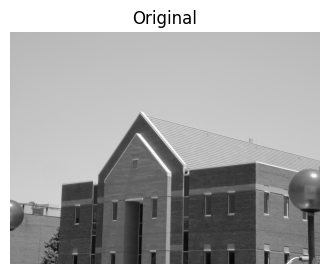

In [11]:
# 영상 로드 (grayscale)
img = cv2.imread('data/school.jpg', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

#### 대각선 Sobel 마스크 설계

표준 Sobel 연산자는 수평/수직 방향의 edge를 검출한다:  
- Gx (수직 edge): `[[-1,0,1],[-2,0,2],[-1,0,1]]`  
- Gy (수평 edge): `[[-1,-2,-1],[0,0,0],[1,2,1]]`  

이를 45° 회전시키면 대각선 edge 검출 마스크를 얻을 수 있다:  
- **+45° 방향 edge** (↗ 방향 gradient): `[[ 0, 1, 2],[-1, 0, 1],[-2,-1, 0]]`  
- **-45° 방향 edge** (↘ 방향 gradient): `[[-2,-1, 0],[-1, 0, 1],[ 0, 1, 2]]`

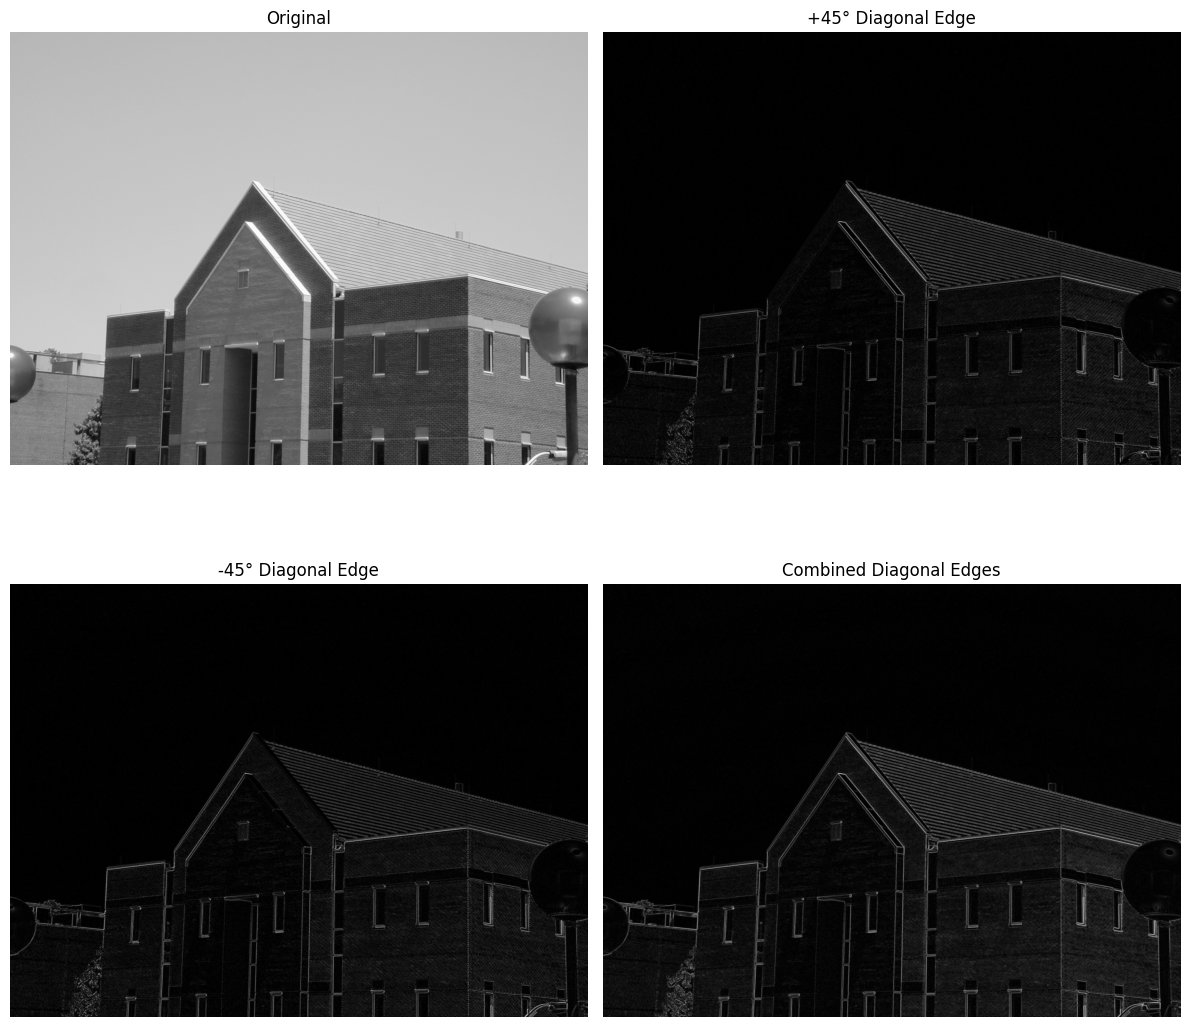

In [ ]:
# 대각선 Sobel 마스크 정의
# +45° 방향 edge 검출 마스크
sobel_45 = np.array([[ 0,  1,  2],
                     [-1,  0,  1],
                     [-2, -1,  0]], dtype=np.float64)

# -45° 방향 edge 검출 마스크
sobel_n45 = np.array([[-2, -1,  0],
                      [-1,  0,  1],
                      [ 0,  1,  2]], dtype=np.float64)

# 컨볼루션 적용
img_float = img.astype(np.float64)

# filter2D로 컨볼루션 (ddepth=-1은 입력과 같은 depth, CV_64F로 음수값 보존)
edge_45 = cv2.filter2D(img_float, cv2.CV_64F, sobel_45)
edge_n45 = cv2.filter2D(img_float, cv2.CV_64F, sobel_n45)

# 절대값 취해서 시각화용으로 변환
edge_45_abs = np.abs(edge_45)
edge_n45_abs = np.abs(edge_n45)

# 두 대각선 edge 합성 (magnitude)
edge_combined = np.sqrt(edge_45**2 + edge_n45**2)

# 0~255로 정규화
def normalize_to_uint8(img):
    return np.clip(img / img.max() * 255, 0, 255).astype(np.uint8)

edge_45_vis = normalize_to_uint8(edge_45_abs)
edge_n45_vis = normalize_to_uint8(edge_n45_abs)
edge_combined_vis = normalize_to_uint8(edge_combined)

# 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].se2222t_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(edge_45_vis, cmap='gray')
axes[0, 1].set_title('+45° Diagonal Edge')
axes[0, 1].axis('off')

axes[1, 0].imshow(edge_n45_vis, cmap='gray')
axes[1, 0].set_title('-45° Diagonal Edge')
axes[1, 0].axis('off')

axes[1, 1].imshow(edge_combined_vis, cmap='gray')
axes[1, 1].set_title('Combined Diagonal Edges')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_4_result.png', dpi=150, bbox_inches='tight')
plt.show()

### HW2-5
왼쪽의 지문영상을 오른쪽 영상과 같이 개선해보세요. 수업시간에 배운 방법을 기본적으로 적용해보고, 더 좋은 방법이 있으면 해당 방법도 적용하고 결과를 분석해보세요.

Image shape: (238, 315), dtype: uint8


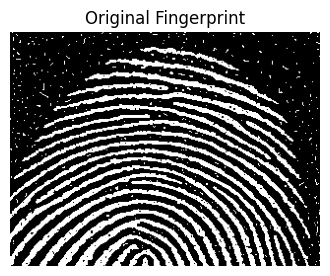

In [12]:
# 영상 로드
img = cv2.imread('data/finger.jpg', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title('Original Fingerprint')
plt.axis('off')
plt.show()

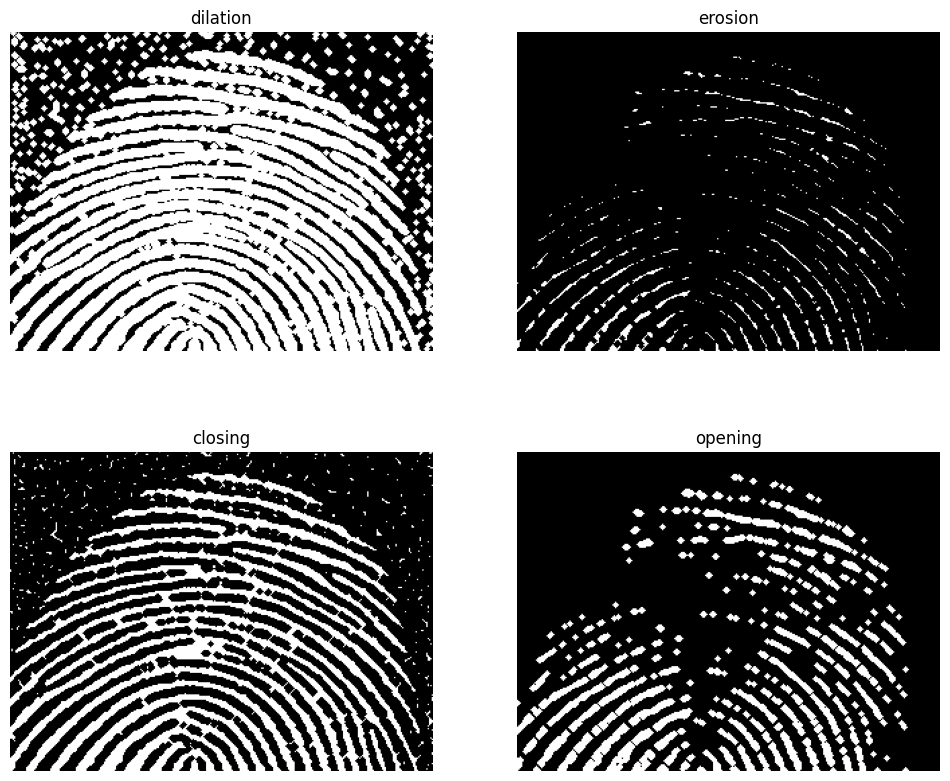

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

se = np.uint8([[0,0,1,0,0],
               [0,1,1,1,0],
               [1,1,1,1,1],
               [0,1,1,1,0],
               [0,0,1,0,0]])

b_dilatioin = cv2.dilate(img,se,iterations=1)
axes[0,0].imshow(b_dilatioin,cmap = 'gray')
axes[0,0].set_title('dilation')
axes[0,0].axis('off')

b_erosion = cv2.erode(img,se,iterations=1)
axes[0,1].imshow(b_erosion,cmap = 'gray')
axes[0,1].set_title('erosion')
axes[0,1].axis('off')

b_closing=cv2.erode(cv2.dilate(img,se,iterations=1),se,iterations=1)
axes[1,0].imshow(b_closing,cmap = 'gray')
axes[1,0].set_title('closing')
axes[1,0].axis('off')

b_opening=cv2.dilate(cv2.erode(img,se,iterations=1),se,iterations=1)
axes[1,1].imshow(b_opening,cmap = 'gray')
axes[1,1].set_title('opening')
axes[1,1].axis('off')

plt.show()


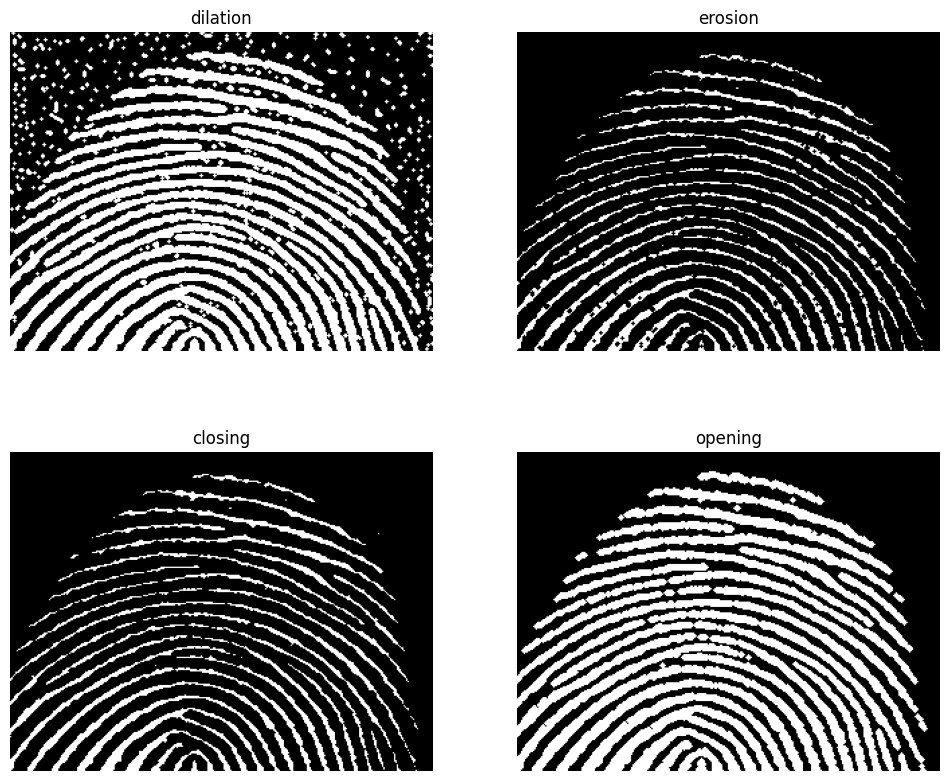

In [33]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

se2 = np.uint8([[0,1,0],
                [1,1,1],
                [0,1,0]])

b_dilatioin = cv2.dilate(img,se2,iterations=1)
axes[0,0].imshow(b_dilatioin,cmap = 'gray')
axes[0,0].set_title('dilation')
axes[0,0].axis('off')

b_erosion = cv2.erode(img,se2,iterations=1)
axes[0,1].imshow(b_erosion,cmap = 'gray')
axes[0,1].set_title('erosion')
axes[0,1].axis('off')

b_closing=cv2.erode(cv2.dilate(img,se2,iterations=1),se,iterations=1)
axes[1,0].imshow(b_closing,cmap = 'gray')
axes[1,0].set_title('closing')
axes[1,0].axis('off')

b_opening=cv2.dilate(cv2.erode(img,se2,iterations=1),se,iterations=1)
axes[1,1].imshow(b_opening,cmap = 'gray')
axes[1,1].set_title('opening')
axes[1,1].axis('off')

plt.show()


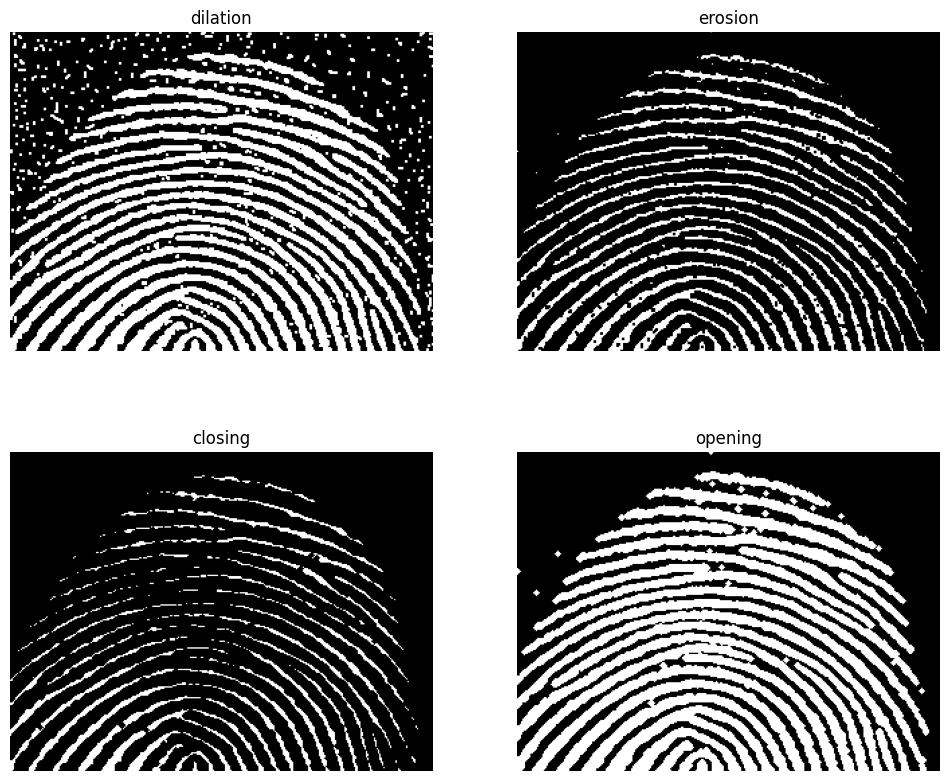

In [34]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

se3 = np.uint8([[1,1],
                [1,1]])

b_dilatioin = cv2.dilate(img,se3,iterations=1)
axes[0,0].imshow(b_dilatioin,cmap = 'gray')
axes[0,0].set_title('dilation')
axes[0,0].axis('off')

b_erosion = cv2.erode(img,se3,iterations=1)
axes[0,1].imshow(b_erosion,cmap = 'gray')
axes[0,1].set_title('erosion')
axes[0,1].axis('off')

b_closing=cv2.erode(cv2.dilate(img,se3,iterations=1),se,iterations=1)
axes[1,0].imshow(b_closing,cmap = 'gray')
axes[1,0].set_title('closing')
axes[1,0].axis('off')

b_opening=cv2.dilate(cv2.erode(img,se3,iterations=1),se,iterations=1)
axes[1,1].imshow(b_opening,cmap = 'gray')
axes[1,1].set_title('opening')
axes[1,1].axis('off')

plt.show()


#### 결과 분석
세가지 SE를 적용해 본 결과 너무 큰 SE를 활용하면 morhorogy를 사용해 얻는 효과보다 손해가 더 컸다.

### HW2-6
다음 영상에서 원하는 선분을 없애 보시고, 어떻게 했는지 분석하세요.

Image shape: (486, 486), dtype: uint8


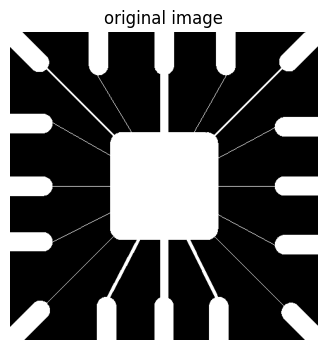

In [38]:
# 영상 로드
img = cv2.imread('data/Fig0905(a)(wirebond-mask).tif', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title('original image')
plt.axis('off')
plt.show()

### HW2-7
아래의 Edge 검출 알고리즘 사용하여 edge를 검출하고, 각각 결과가 어떻게 다른 지 비교하세요.
- Sobel
- Laplacian
- Canny
- Morphological Gradient

### HW2-8

아래의 알고리즘을 사용하여 노이즈라 생각되는 영역을 지우고, 각각 결과가 어떻게 다른 지 비교 분석하세요.
- Morphological Smoothing
- Smoothing Filter

### HW2-9
다음 영상을 이진화하되, 수업시간에 배운 2가지 방법을 모두 써보고, 각각의 결과에 대해 비교 분석하세요.

### HW2-10
다음 영상을 Morphology를 적용하여 오른쪽과 같이 분할하세요.